# Análisis General del Pipeline

Este notebook consolida los resultados de todas las herramientas del pipeline (SBOM, Gitleaks, Grype, CodeQL) para obtener una vista unificada del estado de seguridad de los repositorios analizados.

**Herramientas cubiertas:** Syft · Gitleaks · Grype · CodeQL  
**Objetivo:** Identificar qué repositorios tienen mayor superficie de riesgo y qué categorías de hallazgos predominan.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RESULTS_DIR = Path('../../data/results')
assert RESULTS_DIR.exists(), f'Directorio no encontrado: {RESULTS_DIR}'

## 1. Descubrimiento de repositorios analizados

In [2]:
def _repos_from_suffix(suffix: str) -> set[str]:
    return {f.name.replace(suffix, '') for f in RESULTS_DIR.glob(f'*{suffix}')}

repos_sbom      = _repos_from_suffix('-sbom.json')
repos_gitleaks  = _repos_from_suffix('-gitleaks.json')
repos_grype     = _repos_from_suffix('-grype.json')
repos_codeql    = _repos_from_suffix('-codeql.json')

todos_repos = repos_sbom | repos_gitleaks | repos_grype | repos_codeql

cobertura = pd.DataFrame(index=sorted(todos_repos), columns=['sbom','gitleaks','grype','codeql'])
for repo in todos_repos:
    cobertura.loc[repo, 'sbom']     = '✓' if repo in repos_sbom     else '✗'
    cobertura.loc[repo, 'gitleaks'] = '✓' if repo in repos_gitleaks  else '✗'
    cobertura.loc[repo, 'grype']    = '✓' if repo in repos_grype     else '✗'
    cobertura.loc[repo, 'codeql']   = '✓' if repo in repos_codeql    else '✗'

print(f'Repositorios detectados: {len(todos_repos)}')
cobertura

Repositorios detectados: 5


,sbom,gitleaks,grype,codeql
Requests,✓,✓,✗,✓
WordPress,✓,✓,✓,✗
WordPress-Coding-Standards,✓,✓,✗,✓
gutenberg,✓,✓,✓,✗
wordpress-develop,✓,✓,✓,✓


## 2. Consolidación de hallazgos por repositorio y herramienta

In [3]:
def _load_json(path: Path) -> dict | list:
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    return {}

filas = []
for repo in sorted(todos_repos):
    sbom_data     = _load_json(RESULTS_DIR / f'{repo}-sbom.json')
    gitleaks_data = _load_json(RESULTS_DIR / f'{repo}-gitleaks.json')
    grype_data    = _load_json(RESULTS_DIR / f'{repo}-grype.json')
    codeql_data   = _load_json(RESULTS_DIR / f'{repo}-codeql.json')

    n_componentes = len(sbom_data.get('artifacts', []))
    n_secretos    = gitleaks_data.get('total_hallazgos', 0) if isinstance(gitleaks_data, dict) else len(gitleaks_data)
    n_vulns_dep   = grype_data.get('total_vulnerabilities', 0)
    n_vulns_code  = codeql_data.get('total_issues', 0)

    filas.append({
        'repositorio':        repo,
        'componentes_sbom':   n_componentes,
        'secretos_gitleaks':  n_secretos,
        'vulns_dependencias': n_vulns_dep,
        'vulns_codigo':       n_vulns_code,
        'total_hallazgos':    n_secretos + n_vulns_dep + n_vulns_code,
    })

df = pd.DataFrame(filas).set_index('repositorio')
df

,componentes_sbom,secretos_gitleaks,vulns_dependencias,vulns_codigo,total_hallazgos
repositorio,,,,,
Requests,28,0,0,0,0
WordPress,5,216,1,0,217
WordPress-Coding-Standards,15,0,0,0,0
gutenberg,3988,31,162,0,193
wordpress-develop,251,9,4,683,696


## 3. Ranking por volumen total de hallazgos

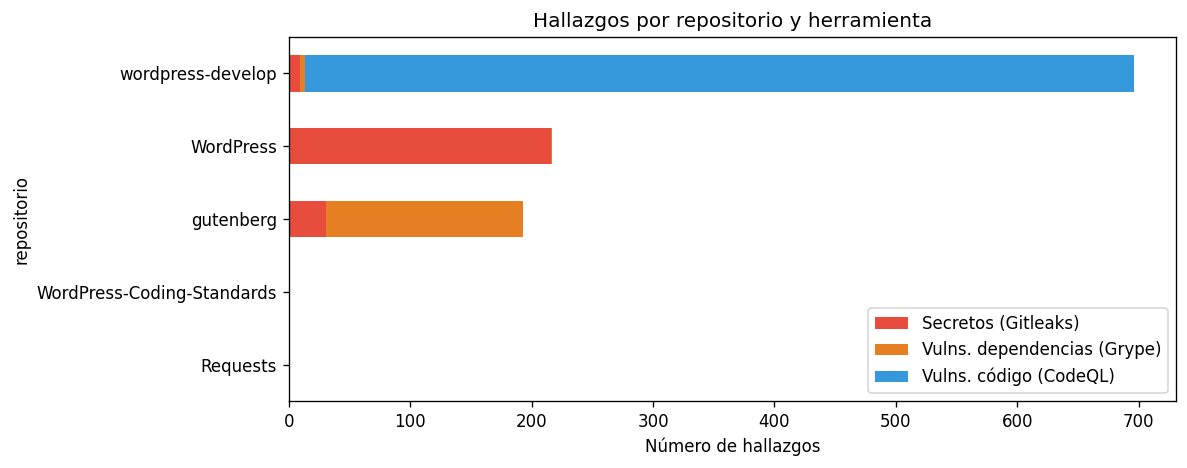

In [4]:
cols_hallazgos = ['secretos_gitleaks', 'vulns_dependencias', 'vulns_codigo']
colores = ['#e74c3c', '#e67e22', '#3498db']

orden = df['total_hallazgos'].sort_values(ascending=True).index
fig, ax = plt.subplots(figsize=(10, max(4, len(orden) * 0.5)))
df.loc[orden, cols_hallazgos].plot(
    kind='barh', stacked=True, ax=ax, color=colores
)
ax.set_title('Hallazgos por repositorio y herramienta')
ax.set_xlabel('Número de hallazgos')
ax.legend(['Secretos (Gitleaks)', 'Vulns. dependencias (Grype)', 'Vulns. código (CodeQL)'],
          loc='lower right')
plt.tight_layout()
plt.show()

## 4. Distribución proporcional de hallazgos por categoría

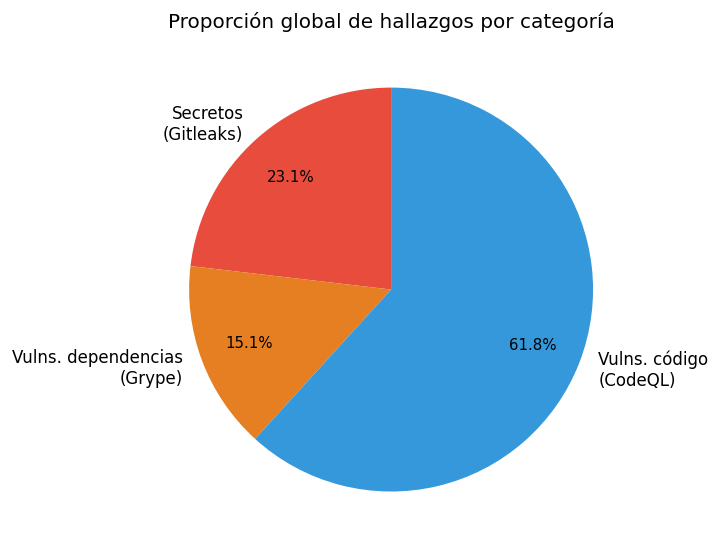

secretos_gitleaks     256
vulns_dependencias    167
vulns_codigo          683
Total global: 1106


In [5]:
totales = df[cols_hallazgos].sum()
etiquetas = ['Secretos\n(Gitleaks)', 'Vulns. dependencias\n(Grype)', 'Vulns. código\n(CodeQL)']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    totales, labels=etiquetas, autopct='%1.1f%%',
    colors=colores, startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Proporción global de hallazgos por categoría')
plt.tight_layout()
plt.show()

print(totales.to_string())
print(f'Total global: {totales.sum()}')

## 5. Resumen estadístico

In [6]:
resumen = df.describe().round(1)
print('Estadísticas por columna:')
resumen

Estadísticas por columna:


,componentes_sbom,secretos_gitleaks,vulns_dependencias,vulns_codigo,total_hallazgos
count,5.0,5.0,5.0,5.0,5.0
mean,857.4,51.2,33.4,136.6,221.2
std,1753.0,93.0,71.9,305.4,284.7
min,5.0,0.0,0.0,0.0,0.0
25%,15.0,0.0,0.0,0.0,0.0
50%,28.0,9.0,1.0,0.0,193.0
75%,251.0,31.0,4.0,0.0,217.0
max,3988.0,216.0,162.0,683.0,696.0


## 6. Heatmap de riesgo relativo por repositorio

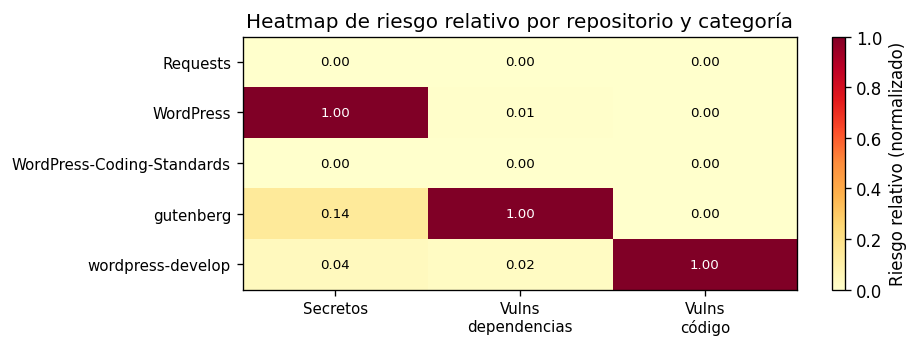

In [7]:
import numpy as np

heat_cols = cols_hallazgos
mat = df[heat_cols].copy().astype(float)
# Normalizar por columna entre 0 y 1
for c in heat_cols:
    mx = mat[c].max()
    mat[c] = mat[c] / mx if mx > 0 else 0

fig, ax = plt.subplots(figsize=(8, max(3, len(mat) * 0.5)))
im = ax.imshow(mat.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(heat_cols)))
ax.set_xticklabels(['Secretos', 'Vulns\ndependencias', 'Vulns\ncódigo'], fontsize=9)
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Riesgo relativo (normalizado)')
ax.set_title('Heatmap de riesgo relativo por repositorio y categoría')
for i in range(len(mat)):
    for j in range(len(heat_cols)):
        v = mat.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.6 else 'black')
plt.tight_layout()
plt.show()